Epoch 1/5
235/235 [==============================] - 2s 6ms/step - loss: 0.2439
Epoch 2/5
235/235 [==============================] - 1s 6ms/step - loss: 0.1431
Epoch 3/5
235/235 [==============================] - 1s 5ms/step - loss: 0.1181
Epoch 4/5
235/235 [==============================] - 1s 5ms/step - loss: 0.1041
Epoch 5/5
235/235 [==============================] - 1s 5ms/step - loss: 0.0950
Epoch 1/5
235/235 [==============================] - 2s 6ms/step - loss: 0.1442
Epoch 2/5
235/235 [==============================] - 1s 6ms/step - loss: 0.1238
Epoch 3/5
235/235 [==============================] - 1s 6ms/step - loss: 0.1205
Epoch 4/5
235/235 [==============================] - 1s 6ms/step - loss: 0.1185
Epoch 5/5
235/235 [==============================] - 1s 6ms/step - loss: 0.1171
Epoch 1/5
235/235 [==============================] - 2s 7ms/step - loss: 236.5553
Epoch 2/5
235/235 [==============================] - 2s 7ms/step - loss: 185.1589
Epoch 3/5
235/235 [=================

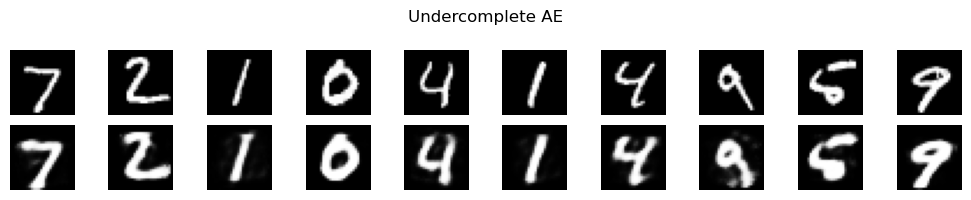

313/313 [==============================] - 0s 1ms/step


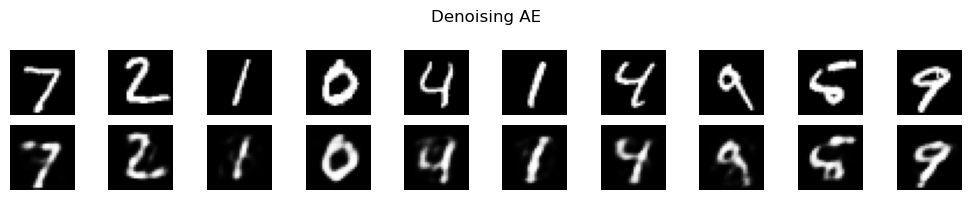

313/313 [==============================] - 0s 1ms/step


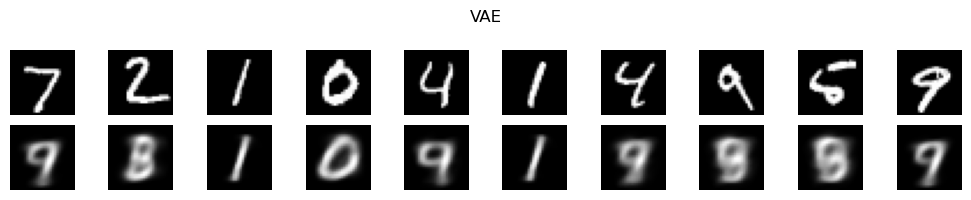

In [2]:
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


# Load & preprocess MNIST

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]


# Add noise for Denoising Autoencoder

def add_noise(x):
    return np.clip(x + 0.5 * np.random.randn(*x.shape), 0., 1.)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)


# Common encoder and decoder layers

enc = models.Sequential([
    layers.Input((28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu')
])

dec = models.Sequential([
    layers.Input((64,)),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28, 28, 1))
])


# 1️⃣ Undercomplete Autoencoder

ucae = models.Sequential([enc, dec])

ucae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

ucae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    verbose=1
)


# 2️⃣ Denoising Autoencoder

dnae = models.Sequential([enc, dec])

dnae.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

dnae.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=256,
    verbose=1
)


# 3️⃣ Variational Autoencoder (fixed)

class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(shape=tf.shape(z_mean))

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# Encoder for VAE

inputs = layers.Input(shape=(28, 28, 1))

x = layers.Flatten()(inputs)

x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(2, name="z_mean")(x)

z_log_var = layers.Dense(2, name="z_log_var")(x)

z = Sampling()([z_mean, z_log_var])

encoder = tf.keras.Model(
    inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)


# Decoder for VAE

latent_inputs = layers.Input(shape=(2,))

x = layers.Dense(128, activation="relu")(latent_inputs)

x = layers.Dense(784, activation="sigmoid")(x)

outputs = layers.Reshape((28, 28, 1))(x)

decoder = tf.keras.Model(
    latent_inputs,
    outputs,
    name="decoder"
)


# Custom VAE class

class VAE(tf.keras.Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)

        reconstruction = self.decoder(z)

        # Compute loss inside the model
        recon_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(inputs, reconstruction)
        ) * 784

        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        self.add_loss(recon_loss + kl_loss)

        return reconstruction


# Compile and train VAE

vae = VAE(encoder, decoder)

vae.compile(optimizer="adam")

vae.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    verbose=1
)


# Plotting function

def show_imgs(orig, recon, title):

    plt.figure(figsize=(10, 2))

    n = min(10, len(orig))

    for i in range(n):

        plt.subplot(2, n, i + 1)

        img = orig[i].squeeze() if orig[i].ndim == 3 else orig[i]

        plt.imshow(img, cmap='gray')

        plt.axis('off')

        plt.subplot(2, n, i + n + 1)

        img = recon[i].squeeze() if recon[i].ndim == 3 else recon[i]

        plt.imshow(img, cmap='gray')

        plt.axis('off')

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()


# Visualize reconstructions

show_imgs(x_test, ucae.predict(x_test), "Undercomplete AE")

show_imgs(x_test, dnae.predict(x_test_noisy), "Denoising AE")

show_imgs(x_test, vae.predict(x_test), "VAE")